# yearly table

Makes a table of yearly statistics for results chapter


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.aral import load_grdc_monthly, load_rivers
from src.paths import *

In [2]:
csv_file = BATHYMETRY / "Nachtnebel_table.csv"
df_csv = pd.read_csv(csv_file, sep=";", decimal=",")
df_csv["Year"] = pd.to_datetime(df_csv["Year"], format="%Y")
df_csv.set_index("Year", inplace=True)

In [3]:
df_csv.head()

,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity
Year,,,,,,,,,,
1950-01-01,41.0,0.47,11.9,0.57,9.22,66.06,52.82,1060.17,65273,10.17
1951-01-01,33.4,0.52,13.2,0.65,8.07,59.19,52.72,1054.14,64896,9.74
1952-01-01,55.2,0.41,18.8,0.58,8.78,62.62,52.70,1052.93,64822,10.67
1953-01-01,54.8,0.41,19.5,0.68,9.63,64.11,52.86,1063.12,65440,9.82
1954-01-01,55.1,0.41,21.1,0.64,10.87,62.87,53.12,1081.91,66649,10.21


In [4]:
# # Resample to 5-year mean
# df_5y = df_csv.resample('5YE').mean()
# df_5y.index


In [5]:
# 1. Annual aggregation first (important!)
annual = df_csv.resample("YE").mean()

# 2. Create start-year bins
years = annual.index.year
start_year = (years // 5) * 5

# optional: force a specific origin like 1950
start_year = ((years - 1950) // 5) * 5 + 1950

# 3. Group and average
df_5y = annual.groupby(start_year).mean()

df_5y.index.name = "StartYear"

In [6]:
# df_5y.index = df_5y.index.year

df_5y.head(10)

,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity
StartYear,,,,,,,,,,
1950,47.900,0.444,16.900,0.624,9.314,62.970,52.844,1062.454,65416.0,10.122
1955,43.880,0.464,15.860,0.790,8.968,68.084,53.202,1087.688,67035.4,10.188
1960,36.500,0.524,13.080,1.022,8.862,69.434,52.956,1070.460,65968.2,10.282
1965,39.040,0.526,9.520,1.036,7.544,64.992,51.648,985.646,60415.0,11.208
1970,25.520,0.642,7.740,1.242,6.502,58.766,50.620,923.838,57693.8,11.900
1975,11.500,0.862,1.040,1.274,5.310,52.298,47.684,758.646,53425.6,14.694
1980,5.380,1.658,1.640,2.104,8.134,45.554,44.330,585.360,48255.4,19.100
1985,6.140,1.480,2.680,2.750,87.416,39.786,40.388,406.314,40504.6,25.960
1990,15.176,1.000,4.858,1.000,1.000,1.000,37.310,290.400,33854.0,1.000


In [7]:
df_5y.index

Index([1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000], dtype='int32', name='StartYear')

In [8]:
Syr_kaza = load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Syr_TA = load_grdc_monthly(2316200, name="Syr Darya Tyumen Aryk")
Amu_chatly = load_grdc_monthly(2817100, name="Amu Darya Chatly")

/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/src/aral.py:223: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = Q.resample("Y").sum(min_count=1 if skipna else None)


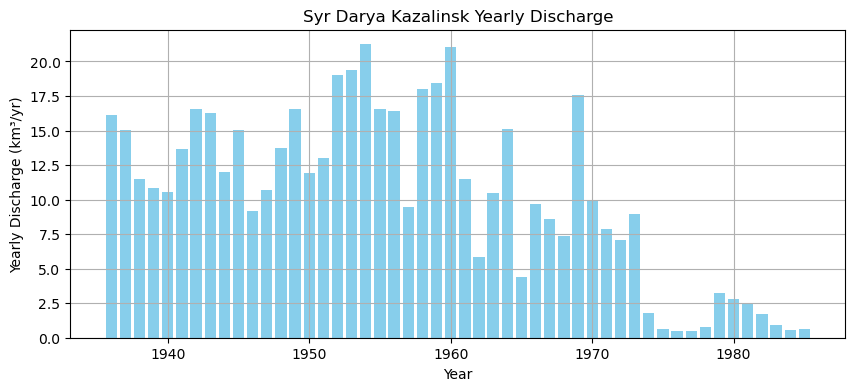

In [9]:
Syr_kaza.plot_yearly()

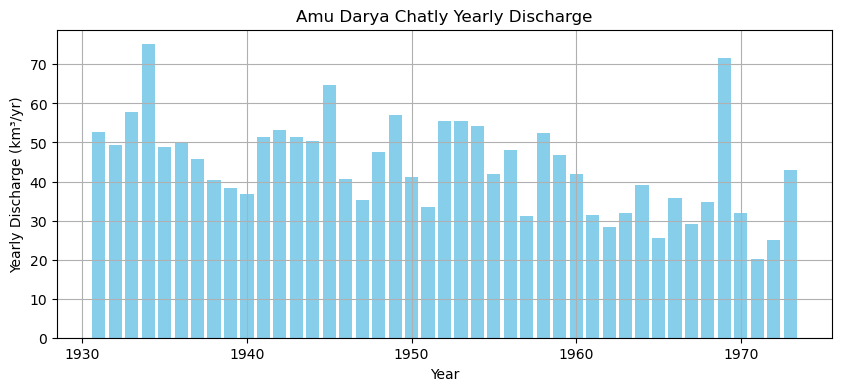

In [10]:
Amu_chatly.plot_yearly()

In [11]:
df_Amu_5 = Amu_chatly.resample_5y_aligned(1930, 2020)

df_Amu_5.head()

,Amu Darya Chatly,bin_label
1930,56.752773,1930-1934
1935,42.237400,1935-1939
1940,54.246033,1940-1944
1945,44.350114,1945-1949
1950,48.129621,1950-1954


In [12]:
df_Syr_5 = Syr_kaza.resample_5y_aligned(1930, 2020)
df_Syr_TA_5 = Syr_TA.resample_5y_aligned(1930, 2020)

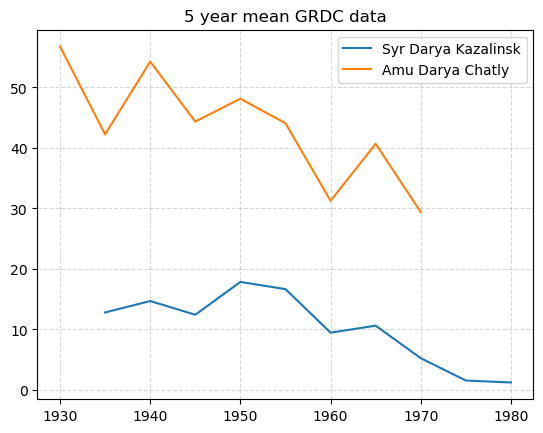

In [13]:
plt.plot(df_Syr_5["Syr Darya Kazalinsk"], label="Syr Darya Kazalinsk")
plt.plot(df_Amu_5["Amu Darya Chatly"], label="Amu Darya Chatly")
plt.grid(linestyle="--", alpha=0.5)
plt.title("5 year mean GRDC data")
plt.legend()

In [14]:
rivers_TA = load_rivers("Tyumen_Aryk_GRDC", scaling_era5=1.0, scaling_cmip=1.0)
rivers_Kerki = load_rivers("Kerki_GRDC", scaling_era5=1.0, scaling_cmip=1.0)
rivers_Chatly = load_rivers("Chatly_GRDC", scaling_era5=1.0, scaling_cmip=1.0)

In [15]:
TA_ERA5 = rivers_TA["ERA5"][0]
TA_ERA5.name = "Tyumen Aryk (ERA5)"
TA_ERA5_5y = TA_ERA5.resample_5y_aligned(1930, 2020)

TA_CMIP = rivers_TA["CMIP_HIST"][0]
TA_CMIP.name = "Tyumen Aryk (CMIP)"
TA_CMIP_5y = TA_CMIP.resample_5y_aligned(1930, 2020)

Chatly_ERA5 = rivers_Chatly["ERA5"][0]
Chatly_ERA5.name = "Chatly (ERA5)"
Chatly_ERA5_5y = Chatly_ERA5.resample_5y_aligned(1930, 2020)

Chatly_CMIP = rivers_Chatly["CMIP_HIST"][0]
Chatly_CMIP.name = "Chatly (CMIP)"
Chatly_CMIP_5y = Chatly_CMIP.resample_5y_aligned(1930, 2020)

In [16]:
TA_ERA5.name

'Tyumen Aryk (ERA5)'

In [17]:
dfs = [
    df_Syr_5,
    df_Syr_TA_5,
    df_Amu_5,
    df_5y,
    Chatly_ERA5_5y,
    Chatly_CMIP_5y,
    TA_ERA5_5y,
    TA_CMIP_5y,
]

# Combine along columns
combined_df = pd.concat(dfs, axis=1)

In [18]:
combined_df

,Syr Darya Kazalinsk,bin_label,Syr Darya Tyumen Aryk,bin_label,Amu Darya Chatly,bin_label,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,...,Area,Salinity,Chatly (ERA5),bin_label,Chatly (CMIP),bin_label,Tyumen Aryk (ERA5),bin_label,Tyumen Aryk (CMIP),bin_label
1930,NaN,1930-1934,22.902218,1930-1934,56.752773,1930-1934,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1930-1934,NaN,1930-1934,NaN,1930-1934,NaN,1930-1934
1935,12.808251,1935-1939,17.720254,1935-1939,42.237400,1935-1939,NaN,NaN,NaN,NaN,...,NaN,NaN,19.269640,1935-1939,24.890877,1935-1939,7.634459,1935-1939,5.250660,1935-1939
1940,14.699923,1940-1944,20.316663,1940-1944,54.246033,1940-1944,NaN,NaN,NaN,NaN,...,NaN,NaN,28.209796,1940-1944,57.292055,1940-1944,11.587014,1940-1944,21.739934,1940-1944
1945,12.434486,1945-1949,18.915296,1945-1949,44.350114,1945-1949,NaN,NaN,NaN,NaN,...,NaN,NaN,27.495323,1945-1949,58.064231,1945-1949,12.112173,1945-1949,18.017554,1945-1949
1950,17.853463,1950-1954,26.418701,1950-1954,48.129621,1950-1954,47.900,0.444,16.900,0.624,...,65416.0,10.122,55.494102,1950-1954,39.756491,1950-1954,23.151876,1950-1954,14.579886,1950-1954
1955,16.665100,1955-1959,24.015986,1955-1959,44.067957,1955-1959,43.880,0.464,15.860,0.790,...,67035.4,10.188,45.498434,1955-1959,46.963401,1955-1959,22.349602,1955-1959,23.435075,1955-1959
1960,9.473567,1960-1964,13.868358,1960-1964,31.256695,1960-1964,36.500,0.524,13.080,1.022,...,65968.2,10.282,46.652145,1960-1964,51.744523,1960-1964,21.705952,1960-1964,20.740503,1960-1964
1965,10.628764,1965-1969,17.175145,1965-1969,40.669093,1965-1969,39.040,0.526,9.520,1.036,...,60415.0,11.208,56.422331,1965-1969,61.011648,1965-1969,28.962845,1965-1969,24.316420,1965-1969
1970,5.258030,1970-1974,10.644540,1970-1974,29.398608,1970-1974,25.520,0.642,7.740,1.242,...,57693.8,11.900,43.257583,1970-1974,36.976751,1970-1974,20.902796,1970-1974,14.592972,1970-1974
1975,1.566895,1975-1979,7.172090,1975-1979,NaN,1975-1979,11.500,0.862,1.040,1.274,...,53425.6,14.694,45.985170,1975-1979,51.797057,1975-1979,23.395947,1975-1979,17.730699,1975-1979


In [19]:
combined_df.columns.tolist()

['Syr Darya Kazalinsk',
 'bin_label',
 'Syr Darya Tyumen Aryk',
 'bin_label',
 'Amu Darya Chatly',
 'bin_label',
 'Amudarya_Q',
 'Amudarya_s',
 'Syrdarya_Q',
 'Syrdarya_s',
 'Precipitation',
 'Evaporation',
 'elevation',
 'Volume',
 'Area',
 'Salinity',
 'Chatly (ERA5)',
 'bin_label',
 'Chatly (CMIP)',
 'bin_label',
 'Tyumen Aryk (ERA5)',
 'bin_label',
 'Tyumen Aryk (CMIP)',
 'bin_label']

In [20]:
label_map = {
    "Syr Darya Kazalinsk": "Syr Darya at Kazalinsk (GRDC)",
    "Syrdarya_Q": "Syr Darya (Technical report)",
    "Amu Darya Chatly": "Amu Darya at Chatly (GRDC)",
    "Amudarya_Q": "Amu Darya (Technical report)",
}

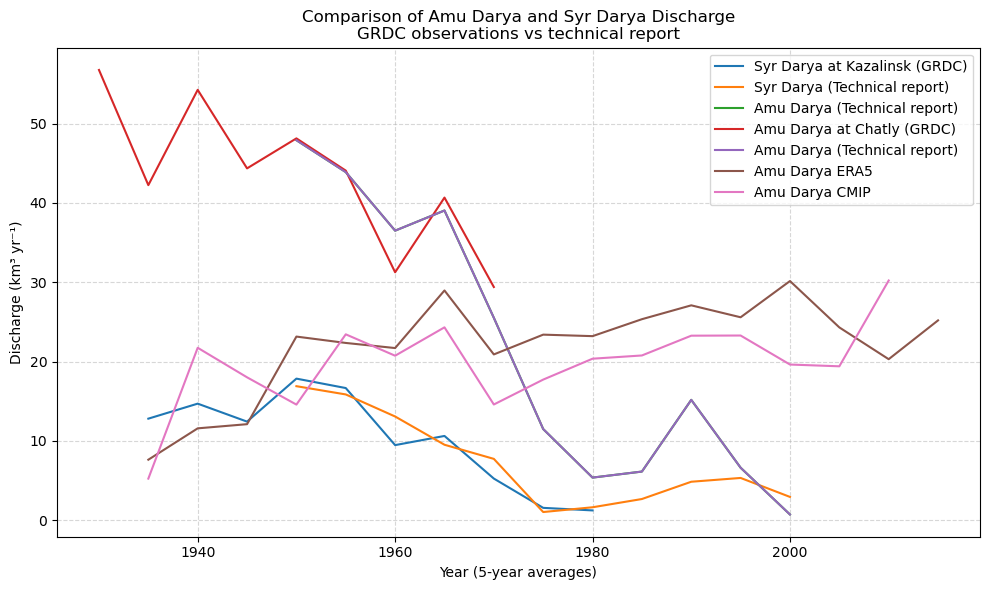

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    combined_df.index,
    combined_df["Syr Darya Kazalinsk"],
    label=label_map["Syr Darya Kazalinsk"],
)
plt.plot(
    combined_df.index,
    combined_df["Syrdarya_Q"],
    label=label_map["Syrdarya_Q"],
)


plt.plot(
    combined_df.index,
    combined_df["Amudarya_Q"],
    label=label_map["Amudarya_Q"],
)


plt.plot(
    combined_df.index,
    combined_df["Amu Darya Chatly"],
    label=label_map["Amu Darya Chatly"],
)
plt.plot(
    combined_df.index,
    combined_df["Amudarya_Q"],
    label=label_map["Amudarya_Q"],
)


plt.plot(
    combined_df.index,
    combined_df.iloc[:, -4],
    label="Amu Darya ERA5",
)


plt.plot(
    combined_df.index,
    combined_df.iloc[:, -2],
    label="Amu Darya CMIP",
)


plt.grid(linestyle="--", alpha=0.5)
plt.legend()
plt.xlabel("Year (5-year averages)")
plt.ylabel("Discharge (km³ yr⁻¹)")  # adjust unit if needed
plt.title("Comparison of Amu Darya and Syr Darya Discharge\nGRDC observations vs technical report")

plt.tight_layout()

In [22]:
discharge_cols = [
    "Syr Darya Kazalinsk",
    "Syrdarya_Q",
    "Tyumen Aryk (ERA5)",
    "Tyumen Aryk (CMIP)",
    "Amu Darya Chatly",
    "Amudarya_Q",
    "Chatly (ERA5)",
    "Chatly (CMIP)",
]

# select columns
table_df = combined_df[discharge_cols].copy()

# set 5-year period as index
table_df["Period"] = combined_df.filter(like="bin_label").iloc[:, 0]
table_df = table_df.set_index("Period")

table_df = table_df.rename(
    columns={
        "Syr Darya Kazalinsk": r"\makecell{Syr Darya\\(GRDC)}",
        "Syrdarya_Q": r"\makecell{Syr Darya\\(report)}",
        "Amu Darya Chatly": r"\makecell{Amu Darya\\(GRDC)}",
        "Amudarya_Q": r"\makecell{Amu Darya\\(report)}",
        "Chatly (ERA5)": r"\makecell{Amu Darya\\(HBV-ERA5)}",
        "Chatly (CMIP)": r"\makecell{Amu Darya\\(HBV-CMIP)}",
        "Tyumen Aryk (ERA5)": r"\makecell{Syr Darya\\(HBV-ERA5)}",
        "Tyumen Aryk (CMIP)": r"\makecell{Syr Darya\\(HBV-CMIP)}",
    }
)

latex = table_df.to_latex(
    float_format="%.2f",
    na_rep="--",
    index=True,
    escape=False,
    caption="Five-year mean river discharges",
    label="tab:five_year_discharge",
)

# Wrap in small font
latex = "\\begin{footnotesize}\n" + latex + "\n\\end{footnotesize}"

# Write to file
with open("five_year_discharge.tex", "w") as f:
    f.write(latex)

In [23]:
# -------------------------------
# Syr Darya table
# -------------------------------
syr_cols = [
    "Syr Darya Kazalinsk",
    "Syr Darya Tyumen Aryk",
    "Syrdarya_Q",
    "Tyumen Aryk (ERA5)",
    "Tyumen Aryk (CMIP)",
]

syr_table = combined_df[syr_cols].copy()
syr_table["Period"] = combined_df.filter(like="bin_label").iloc[:, 0]
syr_table = syr_table.set_index("Period")
syr_table.index.name = "Period"

syr_table = syr_table.rename(
    columns={
        "Syr Darya Kazalinsk": r"\makecell{Syr Darya Kaza\\(GRDC)}",
        "Syr Darya Tyumen Aryk": r"\makecell{Syr Darya TA\\(GRDC)}",
        "Syrdarya_Q": r"\makecell{Syr Darya\\(report)}",
        "Tyumen Aryk (ERA5)": r"\makecell{Syr Darya\\(HBV-ERA5)}",
        "Tyumen Aryk (CMIP)": r"\makecell{Syr Darya\\(HBV-CMIP)}",
    }
)

latex_syr = syr_table.to_latex(
    float_format="%.2f",
    na_rep="--",
    index=True,
    escape=False,
    caption="Five-year mean discharges for Syr Darya",
    label="tab:syr_darya_discharge",
)
latex_syr = "\\begin{small}\n" + latex_syr + "\n\\end{small}"

with open("syr_darya_discharge.tex", "w") as f:
    f.write(latex_syr)

# -------------------------------
# Amu Darya table
# -------------------------------
amu_cols = ["Amu Darya Chatly", "Amudarya_Q", "Chatly (ERA5)", "Chatly (CMIP)"]

amu_table = combined_df[amu_cols].copy()
amu_table["Period"] = combined_df.filter(like="bin_label").iloc[:, 0]
amu_table = amu_table.set_index("Period")
amu_table.index.name = "Period"

amu_table = amu_table.rename(
    columns={
        "Amu Darya Chatly": r"\makecell{Amu Darya\\(GRDC)}",
        "Amudarya_Q": r"\makecell{Amu Darya\\(report)}",
        "Chatly (ERA5)": r"\makecell{Amu Darya\\(HBV-ERA5)}",
        "Chatly (CMIP)": r"\makecell{Amu Darya\\(HBV-CMIP)}",
    }
)

latex_amu = amu_table.to_latex(
    float_format="%.2f",
    na_rep="--",
    index=True,
    escape=False,
    caption="Five-year mean discharges for Amu Darya",
    label="tab:amu_darya_discharge",
)
latex_amu = "\\begin{small}\n" + latex_amu + "\n\\end{small}"

with open("amu_darya_discharge.tex", "w") as f:
    f.write(latex_amu)